# DEX vs CEX: USDC peg-deviation analysis (Challenge #493, Task 2)

How far did **USDC** trade from its 1.0000 USDT peg on a decentralised vs a centralised venue,
hour by hour, over **2025-07-01 to 2025-09-30 (UTC)**?

| | venue | what "price" means here |
|---|---|---|
| **DEX** | Uniswap v3 USDC/USDT 0.01% pool (`0x3416cf6c708da44db2624d63ea0aaef7113527c6`, Ethereum mainnet) | executed price of each swap = `|amount1| / |amount0|` (USDT per USDC) |
| **CEX** | Bybit USDC/USDT spot | executed price of each trade |

Fair price = **1.0000**. Band = **+/-0.1%**, so in-band is `[0.999, 1.001]`. We measure the USDC volume
that trades **outside** that band, per hour, on each venue, plus the executed-price extremes in those hours.

## Data sources (both free, no API key)

- **Uniswap (DEX):** raw `Swap` event logs pulled straight from Ethereum mainnet via public JSON-RPC
  endpoints (`ethereum.publicnode.com`, `eth.drpc.org`) with `eth_getLogs`, decoded by hand
  (`amount0`, `amount1`, `sqrtPriceX96`). One row per swap. See `src/fetch_uniswap.py` + `src/ethlib.py`.
- **Bybit (CEX):** official public per-trade spot dumps,
  `https://public.bybit.com/spot/USDCUSDT/USDCUSDT_<YYYY-MM-DD>.csv.gz` (columns
  `id, timestamp, price, volume, side, rpi`; `volume` is the USDC base amount). See `src/fetch_bybit.py`.

Nothing here needs a paid data provider or an account.

## Method and conventions

- **Executed price.** Per swap or trade, not a candle. On Uniswap it is the swap's effective
  (volume-weighted) price `|amount1|/|amount0|`; both tokens have 6 decimals so the ratio is already
  USDT per USDC. On Bybit it is the trade price.
- **USDC volume.** Uniswap: `|amount0|/1e6`. Bybit: the `volume` column (USDC base).
- **Outside the band.** `abs(price - 1) > 0.001`, evaluated with a `1e-9` tolerance so a trade sitting
  exactly on the edge (0.9990 / 1.0010, deviation == 0.1%) counts as in-band, not outside. Without it,
  IEEE-754 makes `1.0 - 0.999 = 0.0010000000000000009 > 0.001` and the edge leaks in.
- **Dust floor.** A swap or trade must be at least **1 USDC** to count. Sub-dollar Uniswap swaps (e.g.
  0.000003 USDC) produce meaningless `|amount1/amount0|` ratios purely from integer rounding (prices like
  0.33 or 1.33); the floor removes that noise on both venues and moves total volume by under a cent.
- **min/max executed price** in an hour are taken over that venue's outside-band trades (at least 1 USDC).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

ROOT = '..' if os.path.exists('../results') else '.'
D = lambda *p: os.path.join(ROOT, *p)

table  = pd.read_csv(D('results', 'dex_cex_peg_deviation.csv'), parse_dates=['time'])
byb_h  = pd.read_csv(D('data', 'bybit_hourly.csv'), parse_dates=['time'])
uni_ob = pd.read_csv(D('data', 'uniswap_outside_band_swaps.csv'))

print('deliverable table:', table.shape, '(one row per UTC hour)')
print('uniswap outside-band hours:', int((table.uniswap_volume > 0).sum()))
print('bybit   outside-band hours:', int((table.bybit_volume   > 0).sum()))
print('both venues same hour     :', int(((table.uniswap_volume>0)&(table.bybit_volume>0)).sum()))

deliverable table: (2208, 7) (one row per UTC hour)
uniswap outside-band hours: 64
bybit   outside-band hours: 6
both venues same hour     : 3


## The deliverable table

In [2]:
# columns exactly as the challenge asks
print(list(table.columns))
# the rows that actually carry signal
signal = table[(table.uniswap_volume > 0) | (table.bybit_volume > 0)]
print(f'{len(signal)} of {len(table)} hours have outside-band volume on at least one venue')
signal.head(12)

['time', 'uniswap_volume', 'bybit_volume', 'uniswap_min_price', 'uniswap_max_price', 'bybit_min_price', 'bybit_max_price']
67 of 2208 hours have outside-band volume on at least one venue


,time,uniswap_volume,bybit_volume,uniswap_min_price,uniswap_max_price,bybit_min_price,bybit_max_price
40,2025-07-02 16:00:00+00:00,0.000000e+00,1634058.5,NaN,NaN,0.9900,0.9989
307,2025-07-13 19:00:00+00:00,1.729598e+07,0.0,0.969507,0.998858,NaN,NaN
413,2025-07-18 05:00:00+00:00,9.303731e+05,0.0,0.998890,0.998947,NaN,NaN
414,2025-07-18 06:00:00+00:00,3.877519e+05,0.0,0.998938,0.998960,NaN,NaN
415,2025-07-18 07:00:00+00:00,9.432590e+06,0.0,0.998000,0.998995,NaN,NaN
416,2025-07-18 08:00:00+00:00,8.981715e+05,0.0,0.998932,0.998995,NaN,NaN
418,2025-07-18 10:00:00+00:00,0.000000e+00,1107704.0,NaN,NaN,0.9951,0.9989
479,2025-07-20 23:00:00+00:00,1.335355e+07,0.0,0.799524,0.998414,NaN,NaN
480,2025-07-21 00:00:00+00:00,6.414636e+06,0.0,0.988528,0.998878,NaN,NaN
510,2025-07-22 06:00:00+00:00,3.897650e+06,0.0,0.994466,0.998831,NaN,NaN


In [3]:
print(f"total Uniswap outside-band USDC volume : {table.uniswap_volume.sum():,.0f}")
print(f"total Bybit   outside-band USDC volume : {table.bybit_volume.sum():,.0f}")
print()
print("hours where BOTH venues printed outside-band volume:")
both = table[(table.uniswap_volume>0) & (table.bybit_volume>0)]
both

total Uniswap outside-band USDC volume : 308,611,117
total Bybit   outside-band USDC volume : 7,561,934

hours where BOTH venues printed outside-band volume:


,time,uniswap_volume,bybit_volume,uniswap_min_price,uniswap_max_price,bybit_min_price,bybit_max_price
1771,2025-09-12 19:00:00+00:00,3.646147e+05,554.91,0.998858,0.998999,0.9989,0.9989
1772,2025-09-12 20:00:00+00:00,5.383242e+06,1414.55,0.995825,0.998998,0.9989,0.9989
2018,2025-09-23 02:00:00+00:00,3.997859e+05,4395165.79,0.998876,0.998975,0.9988,0.9989


## What the peg actually did

Two very different pictures. The CEX shows a handful of genuine peg-discount episodes (USDC trading
below 1.0 against USDT). The DEX 1bp pool stays glued to the peg at the margin: almost all of its
outside-band volume is large swaps clipping just past the 0.1% edge (0.998 to 0.999), which is ordinary
AMM price impact plus the 1bp fee, not a real peg move.

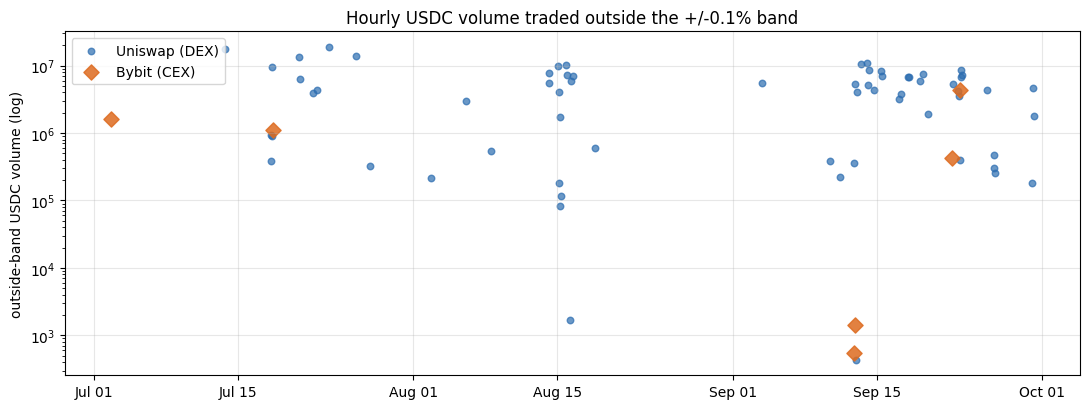

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
u = table[table.uniswap_volume > 0]
b = table[table.bybit_volume > 0]
ax.scatter(u.time, u.uniswap_volume, s=22, alpha=0.7, label='Uniswap (DEX)', color='#2b6cb0')
ax.scatter(b.time, b.bybit_volume, s=60, alpha=0.85, label='Bybit (CEX)', color='#dd6b20', marker='D')
ax.set_yscale('log')
ax.set_ylabel('outside-band USDC volume (log)')
ax.set_title('Hourly USDC volume traded outside the +/-0.1% band')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## The DEX tail is sandwich MEV, not a peg break

Bucketing the DEX outside-band swaps by size shows where the volume lives and where the wild prices live.

In [5]:
ob = uni_ob.copy()
ob['dev'] = (ob.exec_price - 1).abs()
rows = []
for lo, hi, lbl in [(1,100,'1-100'),(100,1_000,'100-1k'),(1_000,10_000,'1k-10k'),(10_000,1e12,'10k+')]:
    s = ob[(ob.usdc_vol>=lo) & (ob.usdc_vol<hi)]
    rows.append({'size bucket (USDC)': lbl, 'swaps': len(s),
                 'sum USDC': round(s.usdc_vol.sum(), 0),
                 'max deviation': round(s.dev.max(), 4) if len(s) else 0,
                 'USDC with dev>1%': round(s[s.dev>0.01].usdc_vol.sum(), 0)})
print(pd.DataFrame(rows).to_string(index=False))
within_1pct = ob[ob.dev<=0.01].usdc_vol.sum() / ob.usdc_vol.sum() * 100
within_02pct = ob[ob.dev<=0.002].usdc_vol.sum() / ob.usdc_vol.sum() * 100
print(f"\nshare of DEX outside-band volume within 1% of peg: {within_1pct:.1f}%  (within 0.2%: {within_02pct:.1f}%)")

size bucket (USDC)  swaps    sum USDC  max deviation  USDC with dev>1%
             1-100    111      4023.0         0.0011               0.0
            100-1k     95     38110.0         0.0026               0.0
            1k-10k     94    364956.0         0.0025               0.0
              10k+    256 308204027.0         0.2005         3863762.0

share of DEX outside-band volume within 1% of peg: 98.7%  (within 0.2%: 83.4%)


In [6]:
# MEV spot-check: the block holding the lowest-priced outside-band swap, with the pool's marginal
# price (from sqrtPriceX96) and the transaction structure.
mev = pd.read_csv(D('data', 'uniswap_mev_example.csv'))
target_block = int(uni_ob.sort_values('exec_price').iloc[0]['block'])
focus = mev[mev.block == target_block].sort_values('tx_index').reset_index(drop=True)
print(f"All swaps in block {target_block}, in transaction order:")
print(focus.to_string(index=False))
front, mid, back = focus.iloc[0], focus.iloc[1], focus.iloc[2]
print()
print(f"tx {int(front.tx_index)} and tx {int(back.tx_index)} share the same sender ({front.sender}): "
      f"{front.sender == back.sender}  <- one actor front-runs and back-runs")
print(f"tx {int(mid.tx_index)} is the victim ({mid.sender}, the Uniswap V3 router), filled at {mid.exec_price}")
print()
print("So this is a verified sandwich. One address pushes the pool marginal price to ~0.80, the victim")
print("sells into that gap, and the same address buys it back to ~1.00, all in one block. The big swaps'")
print("executed AVERAGES stay near peg because the liquidity is at peg; the marginal price and the victim's")
print("fill are what reveal the dislocation. So the DEX outside-band extremes are MEV, not USDC peg moves.")
print("The same dislocate-and-restore shape appears in block 22984299 (up to ~1.10).")

All swaps in block 22963581, in transaction order:
   block  tx_index      side     sender  exec_price  marginal_after   usdc_vol
22963581         0 sell USDC 0xba6d84cc    0.998235        0.799644 6663270.04
22963581         1 sell USDC 0xe592427a    0.799524        0.799564  141542.47
22963581         2  buy USDC 0xba6d84cc    0.998414        0.999544 6548739.73

tx 0 and tx 2 share the same sender (0xba6d84cc): True  <- one actor front-runs and back-runs
tx 1 is the victim (0xe592427a, the Uniswap V3 router), filled at 0.799524

So this is a verified sandwich. One address pushes the pool marginal price to ~0.80, the victim
sells into that gap, and the same address buys it back to ~1.00, all in one block. The big swaps'
executed AVERAGES stay near peg because the liquidity is at peg; the marginal price and the victim's
fill are what reveal the dislocation. So the DEX outside-band extremes are MEV, not USDC peg moves.
The same dislocate-and-restore shape appears in block 22984299 (up 

## CEX peg-discount episodes

Bybit's outside-band hours are all on the discount side. USDC printing below 1.0 against USDT.
This is the genuine cross-venue peg signal.

                     time  bybit_volume  bybit_min_price  bybit_max_price
2025-07-02 16:00:00+00:00    1634058.50           0.9900           0.9989
2025-07-18 10:00:00+00:00    1107704.00           0.9951           0.9989
2025-09-12 19:00:00+00:00        554.91           0.9989           0.9989
2025-09-12 20:00:00+00:00       1414.55           0.9989           0.9989
2025-09-22 06:00:00+00:00     423036.68           0.9987           0.9989
2025-09-23 02:00:00+00:00    4395165.79           0.9988           0.9989



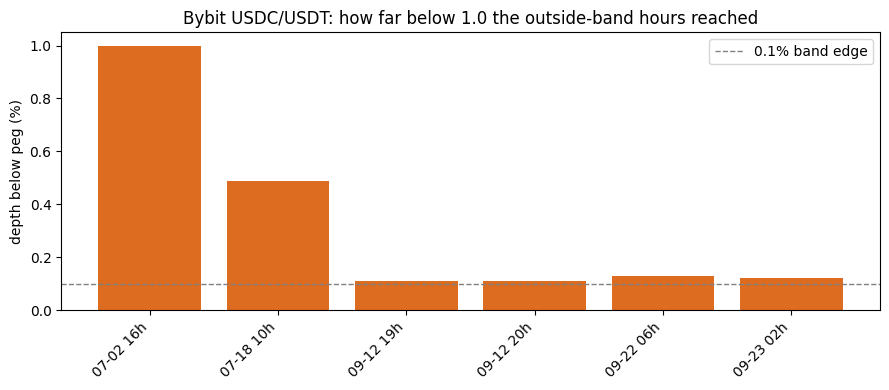

In [7]:
print(byb_h.to_string(index=False))
print()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(byb_h.time.dt.strftime('%m-%d %Hh'), (1 - byb_h.bybit_min_price) * 100, color='#dd6b20')
ax.set_ylabel('depth below peg (%)')
ax.set_title('Bybit USDC/USDT: how far below 1.0 the outside-band hours reached')
ax.axhline(0.1, ls='--', color='grey', lw=1, label='0.1% band edge')
ax.legend(); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## Findings

1. **The two venues behave differently.** Over the quarter the Bybit USDC/USDT order book left the
   +/-0.1% band in **6 hours**, always on the discount side (USDC down to ~0.99 on 2025-07-02), for about
   **$7.6M** of outside-band volume. Real, modest, market-wide peg stress.
2. **The Uniswap 1bp pool holds the peg far tighter.** About **99%** of its ~**$309M** of outside-band
   volume is within 1% of peg, and ~83% within 0.2% (prices 0.998 to 0.999). That is large swaps clipping
   just past the band edge, ordinary AMM impact, not a peg move.
3. **The DEX's wild prices are sandwich MEV, verified on-chain.** Only ~1.3% of DEX outside-band volume
   deviates more than 1%, and it is sandwich attacks, not peg moves. In block 22963581 one address
   (0xba6d84cc) sells $6.7M USDC to push the pool to ~0.80, a victim sells $142k through the Uniswap router
   and is filled at 0.7995, then the same address buys $6.5M back to ~1.00, across three consecutive
   transactions. The same shape appears in block 22984299 (up to ~1.10).
4. **Genuine joint stress is rare.** Both venues printed outside-band volume in only **3 hours**, all USDC
   discount; the clearest is **2025-09-23 02:00 UTC** ($4.4M outside-band on Bybit).

**Takeaway for an investigator:** raw "executed price outside the band" overstates DEX peg stress unless you
separate AMM impact and MEV from real market moves. The CEX trade tape is the cleaner peg gauge here; the
DEX needs the trade size and within-block context applied before any number means what it looks like.

## Reproducibility

```bash
pip install -r requirements.txt
python src/fetch_bybit.py      # Bybit spot dumps  -> data/bybit_hourly.csv
python src/fetch_uniswap.py    # Uniswap swaps     -> data/uniswap_hourly.csv  (resumable)
python src/build_table.py      # merge             -> results/dex_cex_peg_deviation.csv
pytest -q                      # logic tests
```
The pull scripts are deterministic for a fixed block window; `fetch_uniswap.py` resumes if interrupted.